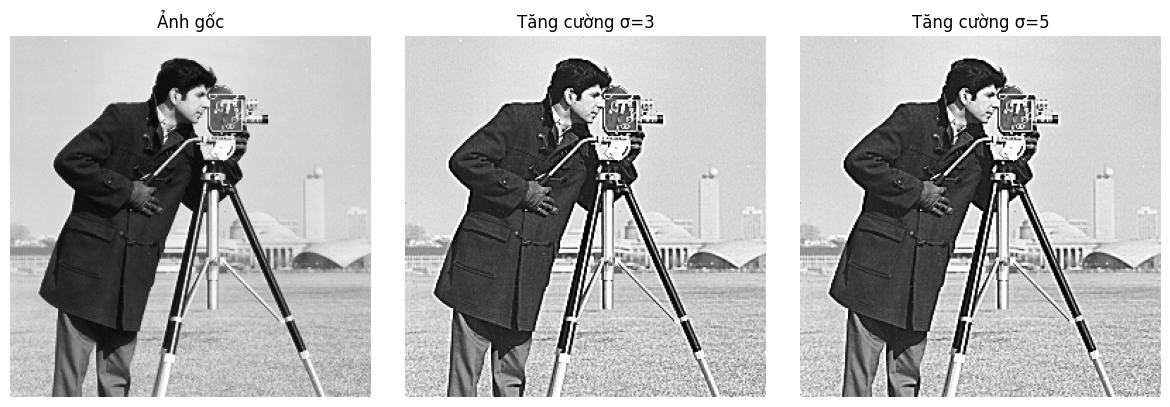

In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Tăng cường ảnh bằng làm sắc nét Gaussian
# Chương/Mục liên quan: Chương 4 - Lọc ảnh và tăng cường chất lượng ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa kỹ thuật tăng cường ảnh dựa trên ảnh làm mượt Gaussian.
# - Giúp người học quan sát ảnh hưởng của tham số sigma đến kết quả tăng cường.
# - Liên hệ thao tác trừ ảnh làm mượt với việc tách thành phần chi tiết của ảnh.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của bộ lọc Gaussian trong việc tạo ảnh làm mượt.
# 2. Hiểu cách lấy thành phần chi tiết bằng hiệu giữa ảnh gốc và ảnh làm mượt.
# 3. Quan sát được ảnh hưởng của sigma đến mức độ tăng cường ảnh.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman.png từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Ảnh tăng cường với sigma = 3
# - Ảnh tăng cường với sigma = 5

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

# Hàm đọc ảnh xám từ URL GitHub
def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

# Đọc ảnh từ kho GitHub
image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"
I = read_gitlab_image(image_uri)

# Kiểm tra ảnh có được đọc thành công hay không
if I is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

# Ảnh đầu vào sẽ được hiển thị cùng với kết quả ở Mục 5

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Hàm tăng cường ảnh bằng cách cộng thêm thành phần chi tiết
def sharpen_gaussian(img, sigma):
    # Làm mượt ảnh bằng bộ lọc Gaussian
    Ig = cv2.GaussianBlur(img, (5, 5), sigmaX=sigma, sigmaY=sigma)

    # Thành phần chi tiết được lấy bằng hiệu giữa ảnh gốc và ảnh làm mượt
    # Dòng này tương ứng với bước tách chi tiết: detail = I - Ig
    detail = img.astype(np.float32) - Ig

    # Ảnh tăng cường được tạo bằng cách cộng chi tiết vào ảnh gốc
    # Dòng này tương ứng với bước tăng cường: Ie = I + detail
    Ie = img + detail

    # Giới hạn giá trị điểm ảnh trong khoảng [0, 255]
    return np.clip(Ie, 0, 255).astype(np.uint8)

# Tăng cường ảnh với hai giá trị sigma khác nhau
Ie3 = sharpen_gaussian(I, sigma=3)
Ie5 = sharpen_gaussian(I, sigma=5)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(I.astype(np.uint8), cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Ie3, cmap='gray')
plt.title('Tăng cường σ=3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Ie5, cmap='gray')
plt.title('Tăng cường σ=5')
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

# Kiểm tra kích thước ảnh đầu ra có bằng kích thước ảnh đầu vào hay không
assert Ie3.shape == I.shape
assert Ie5.shape == I.shape

# Kiểm tra kiểu dữ liệu ảnh đầu ra
assert Ie3.dtype == np.uint8
assert Ie5.dtype == np.uint8

# Kiểm tra giá trị điểm ảnh nằm trong miền hợp lệ [0, 255]
assert Ie3.min() >= 0 and Ie3.max() <= 255
assert Ie5.min() >= 0 and Ie5.max() <= 255

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi sigma, ví dụ sigma = 1, 2, 7, để quan sát mức độ tăng cường ảnh.
# 2. Thay đổi kích thước kernel Gaussian, ví dụ (3, 3), (7, 7), để quan sát ảnh hưởng của vùng lân cận.
# 3. Thay ảnh đầu vào bằng một ảnh xám khác để kiểm tra tính tổng quát của thuật toán.